In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
import emcee
import corner

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [5]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)
        
wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [6]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [7]:
fid_pars = np.array([wind_en[30], wind_vel[30], rho_rec[30], sf_ts[30], ef_kin[30], ef_high[30], f_re[30]])

weights = (0.1, 1, 0.1, 1, 0.1, 0.1, 0.1)

dist = np.zeros(31)
for i in range(len(name_list)):
    pars_i = np.array([wind_en[i], wind_vel[i], rho_rec[i], sf_ts[i], ef_kin[i], ef_high[i], f_re[i]])
    dist[i] = np.sum((weights*(pars_i - fid_pars))**2)

In [8]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

#### Load the MTNG

In [9]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

2026-01-26 17:56:48,188 bacco.sims : Initialising simulation Default
2026-01-26 17:56:48,189 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-01-26 17:56:48,192 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-01-26 17:56:48,222 bacco.sims : ...done in 0.00744 s


### Load the Zooms

In [9]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

loaded = []
for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2026-02-04 21:09:38,044 bacco.sims : Initialising simulation Default
2026-02-04 21:09:38,046 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-02-04 21:09:38,049 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264


2026-02-04 21:09:38,478 bacco.sims : ...done in 0.00891 s
2026-02-04 21:09:38,479 bacco.sims : Initialising simulation Default
2026-02-04 21:09:38,480 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-04 21:09:38,482 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-04 21:09:38,899 bacco.sims : ...done in 0.00742 s
2026-02-04 21:09:38,900 bacco.sims : Initialising simulation Default
2026-02-04 21:09:38,901 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-02-04 21:09:38,903 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-02-04 21:09:38,908 bacco.sims : ...done in 0.00621 s
2026-02-04 21:09:38,909 bacco.sims : Initialising simulation Default
2026-02-04 21:09:38,910 bacco.sims : try /cosmos_storage/simulations/TNG_Fa

In [85]:
Nbins_smf = 15
Nbins_fgas = 8

zoom_smf = {}
for i in range(len(name_list)):
    zoom_smf[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_{}_Nbins{:d}.npy".format(name_list[i], Nbins_smf), allow_pickle=True)[0]

In [86]:
# Filter NaNs
for i in range(len(name_list)):
    mask = ~np.isnan(zoom_smf[name_list[i]]['smf'][0]) & ~np.isnan(zoom_smf[name_list[i]]['mstar'][0])
    
    zoom_smf[name_list[i]]['smf'][0] = zoom_smf[name_list[i]]['smf'][0][mask]
    zoom_smf[name_list[i]]['mstar'][0] = zoom_smf[name_list[i]]['mstar'][0][mask]

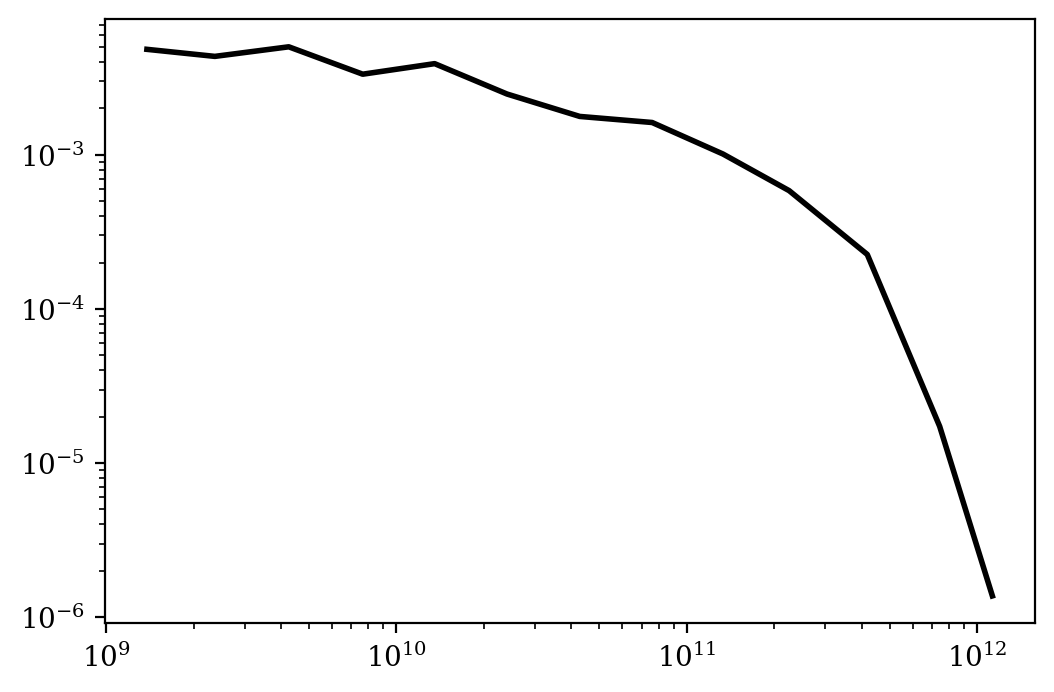

In [87]:
fig, ax = plt.subplots(dpi=200)

ax.set_xscale("log")
ax.set_yscale("log")

ax.plot(zoom_smf['fiducial']['mstar'][0], zoom_smf['fiducial']['smf'][0], label='Fiducial', color='black', linewidth=2)

# for i in range(len(name_list)):
    # ax.plot(zoom_smf[name_list[i]]['mstar'][0], zoom_smf[name_list[i]]['smf'][0], label=name_list[i])

In [88]:
train_sel = np.argsort(dist)[::-1][:25]
test_sel = list(set(range(31)) - set(train_sel))

In [89]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_smf[name_list[train_sel[0]]]['mstar'][0]) )
smf_global = np.log10(zoom_smf[name_list[train_sel[0]]]['smf'][0])

for i in range(len(train_sel)):
    mstar = np.log10(zoom_smf[name_list[train_sel[i]]]['mstar'][0])

    arr = pars(train_sel[i], mstar)

    pars_global = np.vstack((pars_global, arr))

    smf_global = np.hstack((smf_global, np.log10(zoom_smf[name_list[train_sel[i]]]['smf'][0])))

In [90]:
pars_global.shape

(348, 8)

In [91]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

In [92]:
torch.set_num_threads(8)

### Build the GP Model

In [93]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 0.05

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-2))
model = ExactGPModel(train_x, train_y, likelihood)

In [94]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [95]:
# this is for running the notebook in our testing framework
import os
import copy
smoke_test = ('CI' in os.environ)
#training_iter = 2 if smoke_test else 200

n_restarts = 30
steps_per_restart = 30

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model.initialize()

    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model.state_dict()),
            'likelihood': copy.deepcopy(likelihood.state_dict()),
        }


=== Restart 1/30 ===
Final loss restart 1: 1.3784

=== Restart 2/30 ===
Final loss restart 2: 1.2705

=== Restart 3/30 ===
Final loss restart 3: 1.0093

=== Restart 4/30 ===
Final loss restart 4: 0.8966

=== Restart 5/30 ===
Final loss restart 5: 0.7734

=== Restart 6/30 ===
Final loss restart 6: 0.6819

=== Restart 7/30 ===
Final loss restart 7: 0.6118

=== Restart 8/30 ===
Final loss restart 8: 0.5618

=== Restart 9/30 ===
Final loss restart 9: 0.4939

=== Restart 10/30 ===
Final loss restart 10: 0.4591

=== Restart 11/30 ===
Final loss restart 11: 0.4358

=== Restart 12/30 ===
Final loss restart 12: 0.4061

=== Restart 13/30 ===
Final loss restart 13: 0.3768

=== Restart 14/30 ===
Final loss restart 14: 0.3558

=== Restart 15/30 ===
Final loss restart 15: 0.3478

=== Restart 16/30 ===
Final loss restart 16: 0.3257

=== Restart 17/30 ===
Final loss restart 17: 0.3110

=== Restart 18/30 ===
Final loss restart 18: 0.2995

=== Restart 19/30 ===
Final loss restart 19: 0.2833

=== Restar

In [96]:
# ---- restore best ----
model.load_state_dict(best_state['model'])
likelihood.load_state_dict(best_state['likelihood'])

<All keys matched successfully>

In [97]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[0.8937, 8.8706, 5.7332, 5.6265, 8.8300, 7.5382, 8.8330, 8.8418]],
       grad_fn=<SoftplusBackward0>)
tensor(1.1859, grad_fn=<SoftplusBackward0>)
tensor([0.2430], grad_fn=<SqrtBackward0>)


In [98]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

In [101]:
# Stellar Mass Function from  GAMA (corrected to h=0.7)
# https://arxiv.org/pdf/2203.08539
# For SDSS correction, add 0.0807 dex to number density

GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = GAMA[:,0] - 2*np.log10(0.7)
GAMA_corr[:,1] = GAMA[:,1] + 3*np.log10(0.7)


def model_GAMA(GAMA_corr, b_star, b_cv):

    GAMA_corr = np.copy(GAMA_corr)
    GAMA_corr[:,1] = GAMA_corr[:,1] + np.log10(b_cv)
    GAMA_corr[:,0] = GAMA_corr[:,0] + b_star

    return GAMA_corr

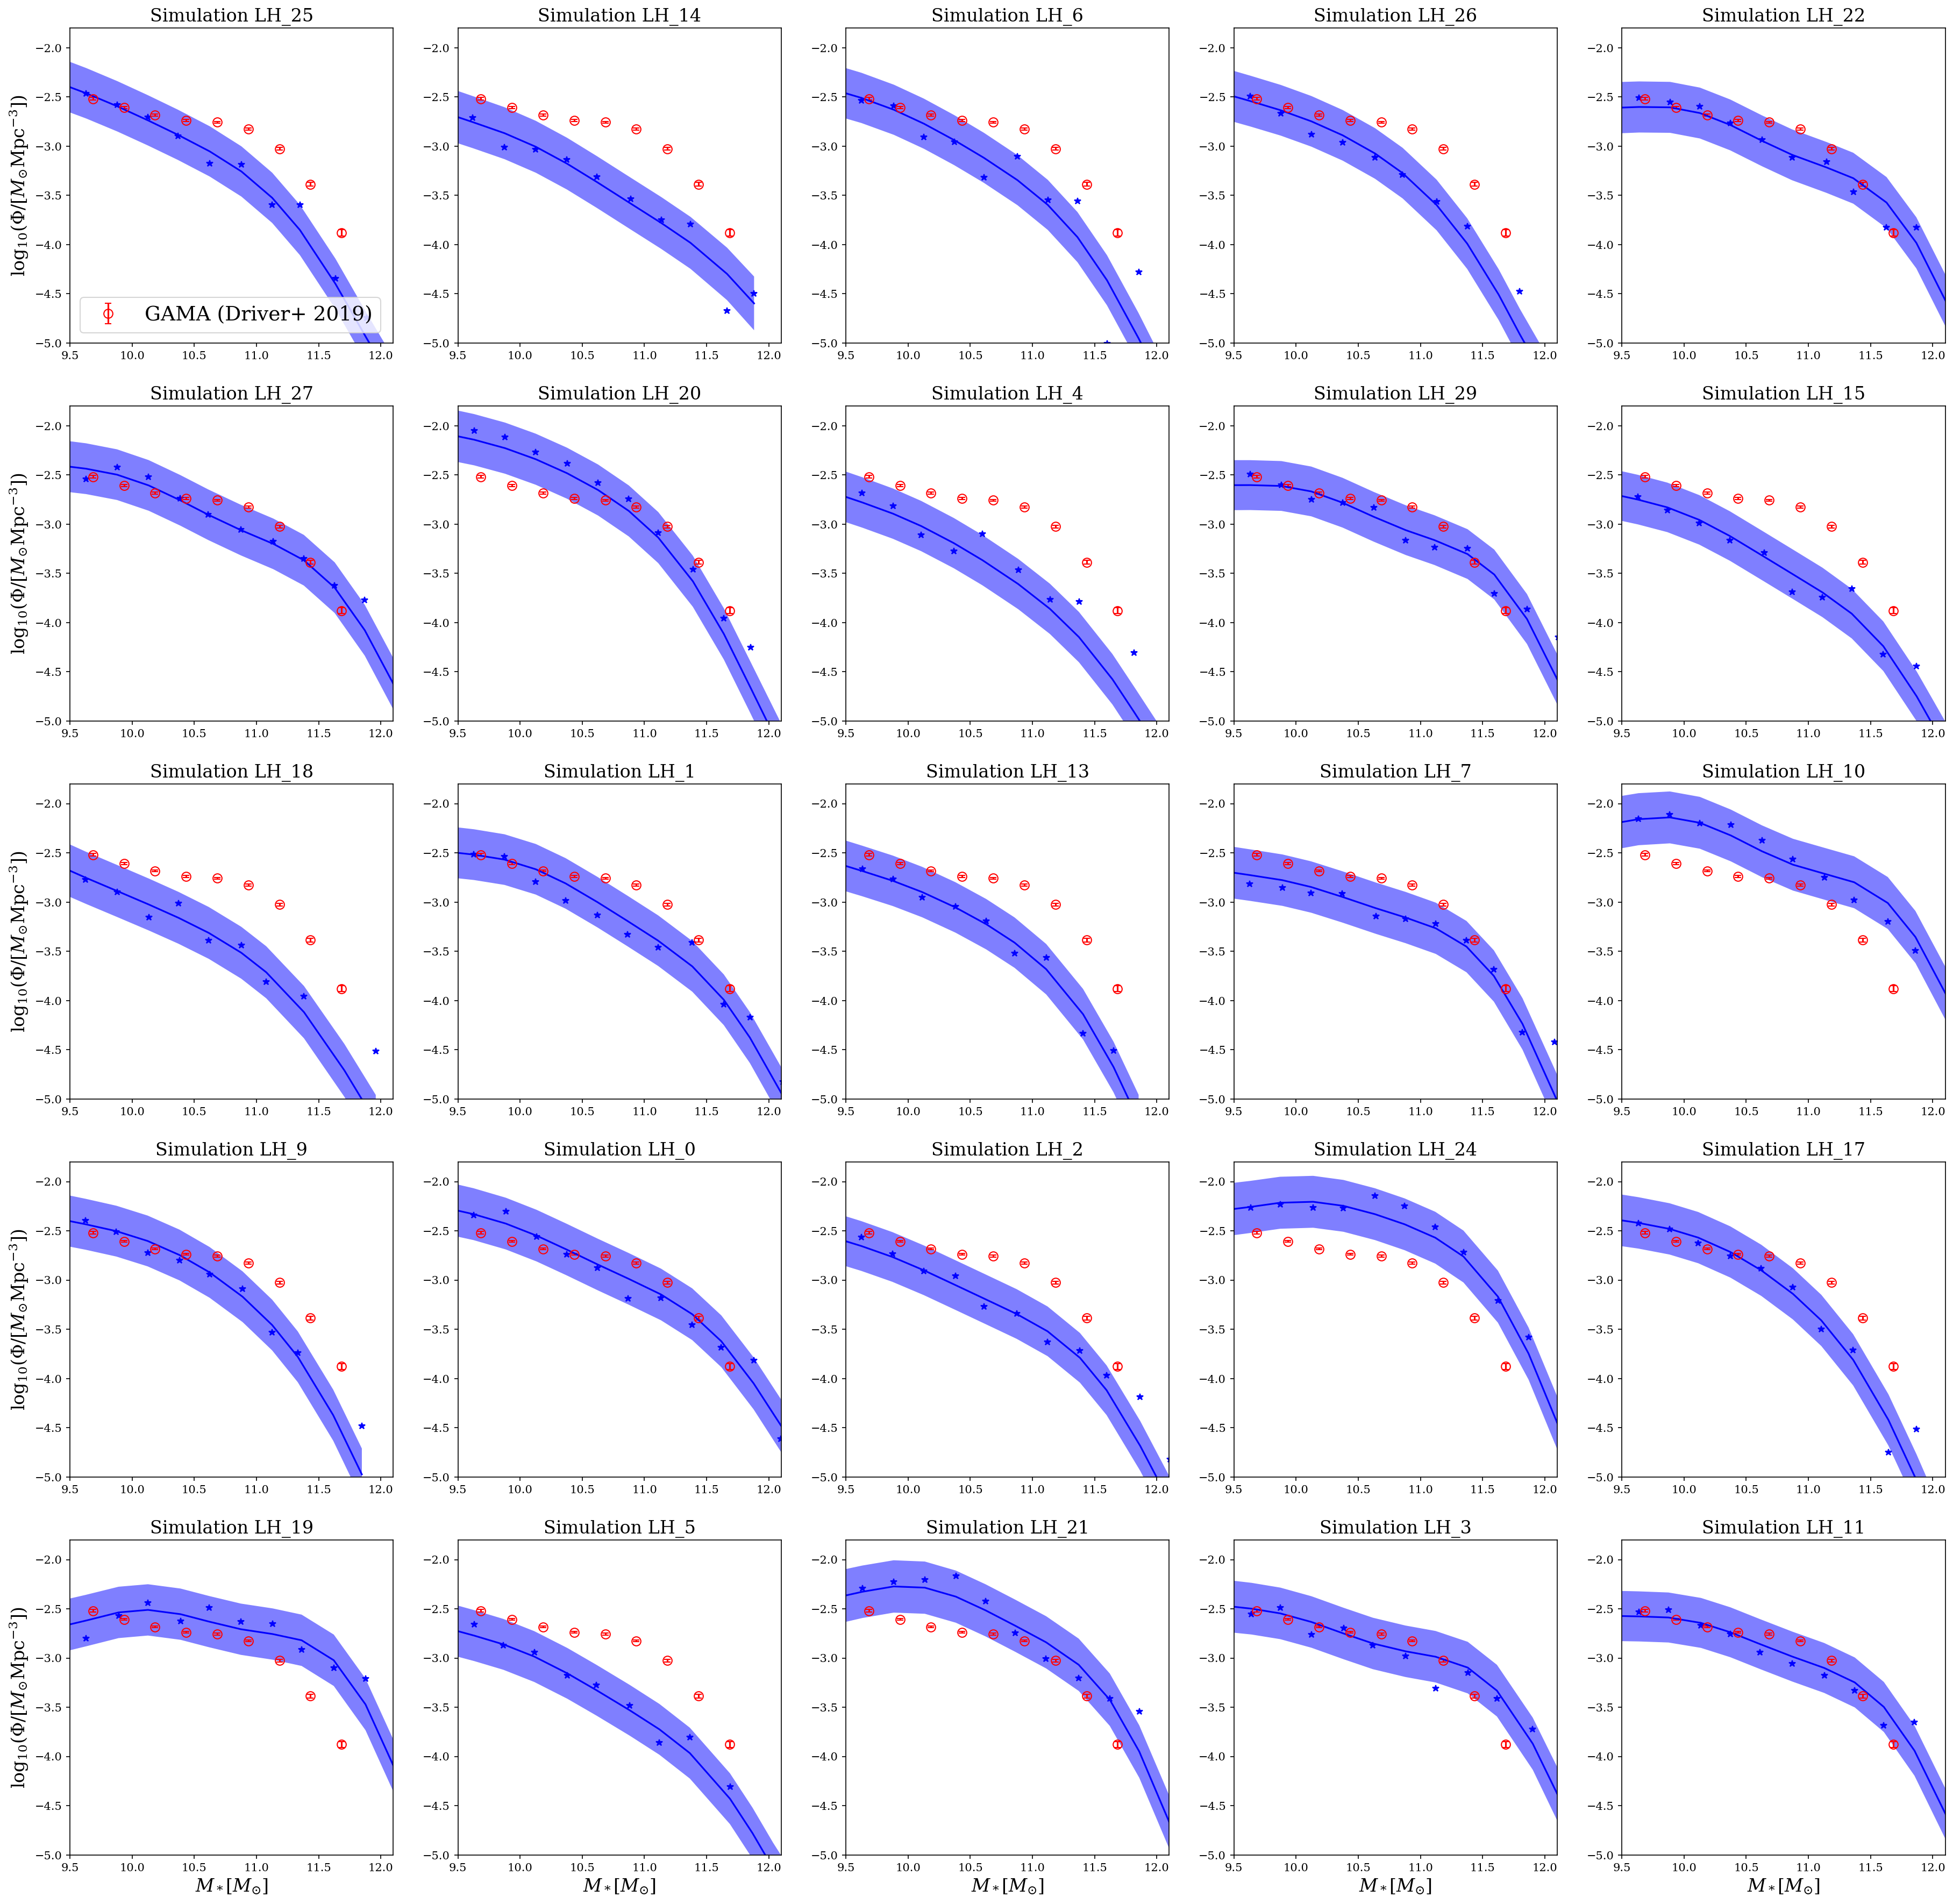

In [104]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(5, 5, figsize=(30, 30), dpi=150)

    for i in range(5):
        for j in range(5):
            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))

            ax[i,j].set_title('Simulation {:s}'.format(name_list[train_sel[5*i+j]]), fontsize=16)
            ax[i,j].errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=GAMA[:,2], color='r', marker='o', capsize=3, ms=8, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

            ax[i,j].set_xlim(9.5,12.1)
            ax[i,j].set_ylim(-5, -1.8)

            if j==0:
                ax[i,j].set_ylabel('$\log_{10}(\Phi/[M_{\odot}\mathrm{Mpc}^{-3}])$', fontsize=16)
            if i==4:
                ax[i,j].set_xlabel('$M_*[M_{\odot}]$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

ax[0,0].legend(loc='lower left', fontsize=18)

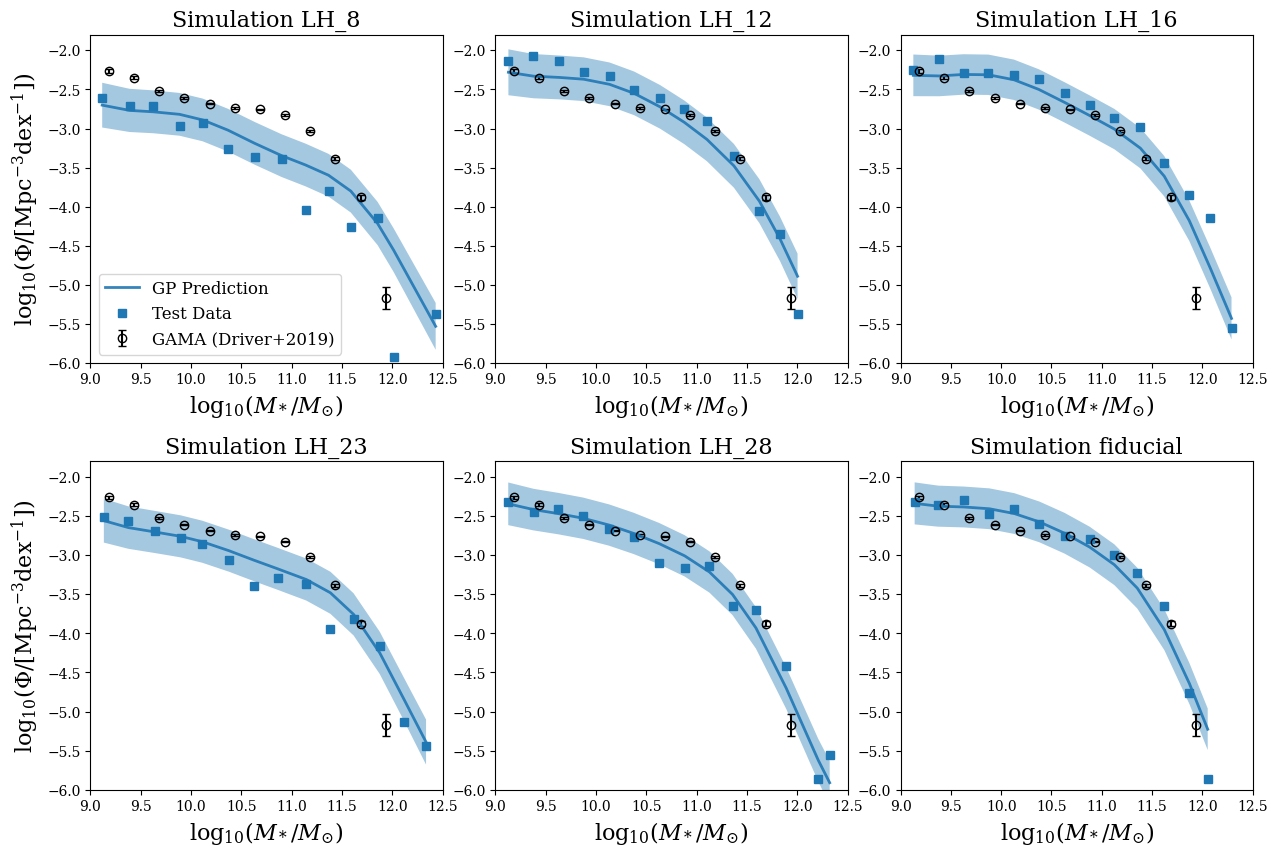

In [159]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 3, figsize=(15, 10), dpi=100)
    plt.subplots_adjust(wspace=0.15, hspace=0.3)

    for i in range(2):
        for j in range(3):
            test_x = torch.asarray(pars(test_sel[3*i+j], np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            ax[i,j].set_xlim(9,12.5)
            ax[i,j].set_ylim(-6, -1.8)

            ax[i,j].set_title('Simulation {:s}'.format(name_list[test_sel[3*i+j]]), fontsize=16)
            ax[i,j].errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=GAMA[:,2], color='k', marker='o', capsize=3, ms=6, fillstyle='none', ls='', label='GAMA (Driver+2019)')

            if j==0:
                ax[i,j].set_ylabel('$\log_{10}(\Phi/[\mathrm{Mpc}^{-3}\mathrm{dex}^{-1}])$', fontsize=16)
            
            ax[i,j].set_xlabel('$\log_{10}(M_*/M_{\odot})$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='C0', alpha=0.4, edgecolor=None)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'C0', lw=2, label="GP Prediction", alpha=0.9)

            # Plot test data as blue squares
            ax[i,j].plot(np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[test_sel[3*i+j]]]['smf'][0]), 's', color="C0", label="Test Data")

ax[0,0].legend(loc='lower left', fontsize=12)

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/testing_plots/smf_test.pdf", bbox_inches='tight')

In [54]:
def prepare_theta(theta):

    theta_std = np.copy(theta)
    
    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

lower_bound = np.asarray([0.9,  3.7,  np.log10(0.005), 0.001135, np.log10(0.001), 0.05, 10, -np.inf, -np.inf])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),   0.00454,  np.log10(2),     0.2,  40, +np.inf, +np.inf])

def log_likelihood_smf(theta, model_GAMA, gp_model, GAMA_corr):
    """
    The log-likelihood function for fitting the Stellar-Mass Function (SMF).
    """

    # Get the observational model
    GAMA_data = model_GAMA(GAMA_corr, theta[7], theta[8])

    obs_log_phi = GAMA_data[9:,1]
    obs_uncertainty = GAMA_data[9:,2]
    mstar = GAMA_data[9:,0]

    # 2. Prepare the input for the GP emulator

    theta_std = prepare_theta(theta)
    theta_vector = np.repeat(theta_std[np.newaxis, :7], len(mstar), axis=0)

    gp_input = np.hstack([
        mstar[:, np.newaxis],
        theta_vector
    ]) 

    # 3. Get the GP prediction for the full SMF curve
    x_star = torch.from_numpy(gp_input).float()     
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive_dist = gp_model(x_star) 
        
    mu_pred = predictive_dist.mean.numpy()
    var_emulator = predictive_dist.variance.numpy()

    # Total variance (Emulator variance + Observation variance)
    total_var = var_emulator + obs_uncertainty**2
    
    # Chi-squared term
    chi2 = (obs_log_phi - mu_pred)**2 / total_var
    
    # Log-likelihood (sum over all mass bins)
    log_p = -0.5 * np.sum(chi2 + np.log(2 * np.pi * total_var))
    
    if not np.isfinite(log_p):
         return -np.inf
    
    return log_p

In [55]:
# The log_prior function is now simple, as the bounds check is integrated into the likelihood
def log_prior(theta):
    # 1. Check for non-physical parameters (Prior check)
    # Define bounds for the 7 physical parameters (theta_1 to theta_7)
    lower_bounds = lower_bound
    upper_bounds = upper_bound
    if not (np.all(theta > lower_bounds) and np.all(theta < upper_bounds)):
        return -np.inf # Implements a flat prior
    else:
        # Prior on b_star
        prior_bstar = -0.5 * ( (theta[7]/0.14)**2 + np.log(2 * np.pi * 0.14**2) )

        # Prior on b_cv
        prior_bcv = -0.5 * ( ( (theta[8]-1)/0.06)**2 + np.log(2 * np.pi * 0.06**2) )

        return prior_bstar + prior_bcv

def log_posterior(theta, model_GAMA, model, GAMA_corr):
    # Note: If log_likelihood returns -inf, this will correctly be -inf.
    return log_prior(theta) + log_likelihood_smf(theta, model_GAMA, model, GAMA_corr)

In [56]:
# --- 3. INITIALIZE AND RUN THE EMCEE SAMPLER (Updated for Convergence Check) ---

ndim = 9  # Number of parameters (7 physical + 2 nuisance)

# MCMC settings
nwalkers = 18 # 14 walkers
p0_start = np.asarray([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), np.mean(sf_ts_or),\
                     np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or), 0, 1])
p0 = p0_start + 1e-4 * np.random.randn(nwalkers, ndim)

sampler_args = (model_GAMA, model, GAMA_corr)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=sampler_args
)

# --- RUNNING MCMC WITH CONVERGENCE CHECK ---
print("Starting MCMC run with convergence monitoring...")

# Initialize variables
max_n = 50000        # Maximum number of steps to allow
autocorr_tol = 0.01  # Tolerance for fractional change in tau (e.g., 1%)
min_steps = 1000     # Minimum number of steps before checking tau
index = 0
old_tau = np.inf

# The main loop that runs the sampler until convergence criteria are met
for sample in sampler.sample(p0, iterations=max_n, progress=False):
    
    # Only check for convergence every 'check_interval' steps
    check_interval = 100
    if sampler.iteration % check_interval:
        continue

    index += 1
    
    # 1. Estimate the autocorrelation time (tau)
    # The default 'c' argument is 50, meaning it requires at least 50 independent samples
    # to estimate tau robustly.
    try:
        # Use discard=0 since we are checking the full chain so far
        tau = sampler.get_autocorr_time(tol=0, discard=0) 
    except emcee.autocorr.AutocorrError:
        # Not enough samples yet to estimate tau. Keep sampling.
        print(f"Step {sampler.iteration}: Not enough samples to estimate tau. Continuing...")
        continue

    # Take the maximum tau across all dimensions
    current_tau = np.max(tau)
    
    # 2. Check for burn-in and chain length convergence
    # We require the chain length to be at least 50 times the estimated tau
    converged = sampler.iteration > (50 * current_tau)

    # 3. Check for stabilization of tau
    # We require the estimated tau to have stabilized (change by less than the tolerance)
    stabilized = np.all(np.abs(old_tau - current_tau) / current_tau < autocorr_tol)
    
    print(f"Step {sampler.iteration}: Max tau = {current_tau:.2f}. Old tau = {old_tau:.2f}. Stabilized: {stabilized}.")

    # Update tau for the next check
    old_tau = current_tau
    
    # Break if both conditions are met AND we are past the minimum steps
    if converged and stabilized and sampler.iteration >= min_steps:
        print("MCMC converged!")
        break

# --- DETERMINE BURN-IN AND PROCESS RESULTS ---

# The optimal burn-in is typically a few times tau (e.g., 3 * tau)
# We must re-estimate tau one last time on the final, full chain.
final_tau = sampler.get_autocorr_time(tol=0, discard=0).max()
burnin = int(2 * final_tau) # Discard 2 times the max autocorrelation time

print(f"\nFinal estimated max autocorrelation time (tau): {final_tau:.2f}")
print(f"Optimal burn-in steps (2 * tau): {burnin}")

# Get the chains (nwalkers * (nsteps - burnin), ndim)
flat_samples = sampler.get_chain(discard=burnin, flat=True)

# ... (Continue with corner plot and summary statistics as before)

Starting MCMC run with convergence monitoring...
Step 100: Max tau = 12.66. Old tau = inf. Stabilized: False.
Step 200: Max tau = 25.86. Old tau = 12.66. Stabilized: False.
Step 300: Max tau = 39.10. Old tau = 25.86. Stabilized: False.
Step 400: Max tau = 51.04. Old tau = 39.10. Stabilized: False.
Step 500: Max tau = 65.44. Old tau = 51.04. Stabilized: False.
Step 600: Max tau = 78.26. Old tau = 65.44. Stabilized: False.
Step 700: Max tau = 93.07. Old tau = 78.26. Stabilized: False.
Step 800: Max tau = 108.11. Old tau = 93.07. Stabilized: False.
Step 900: Max tau = 120.64. Old tau = 108.11. Stabilized: False.
Step 1000: Max tau = 133.55. Old tau = 120.64. Stabilized: False.
Step 1100: Max tau = 149.01. Old tau = 133.55. Stabilized: False.
Step 1200: Max tau = 164.92. Old tau = 149.01. Stabilized: False.
Step 1300: Max tau = 180.88. Old tau = 164.92. Stabilized: False.
Step 1400: Max tau = 192.65. Old tau = 180.88. Stabilized: False.
Step 1500: Max tau = 205.19. Old tau = 192.65. Stabil

In [83]:
param_names = ['WindEnergyIn1e51erg', 'VariableWindVelFactor', 'WindFreeTravelDensFac',\
     'MaxSfrTimescale', 'RadioFeedbackFactor', 'BlackHoleFeedbackFactor', 'RadioFeedbackReiorientationFactor', 'b_star', 'b_cv']

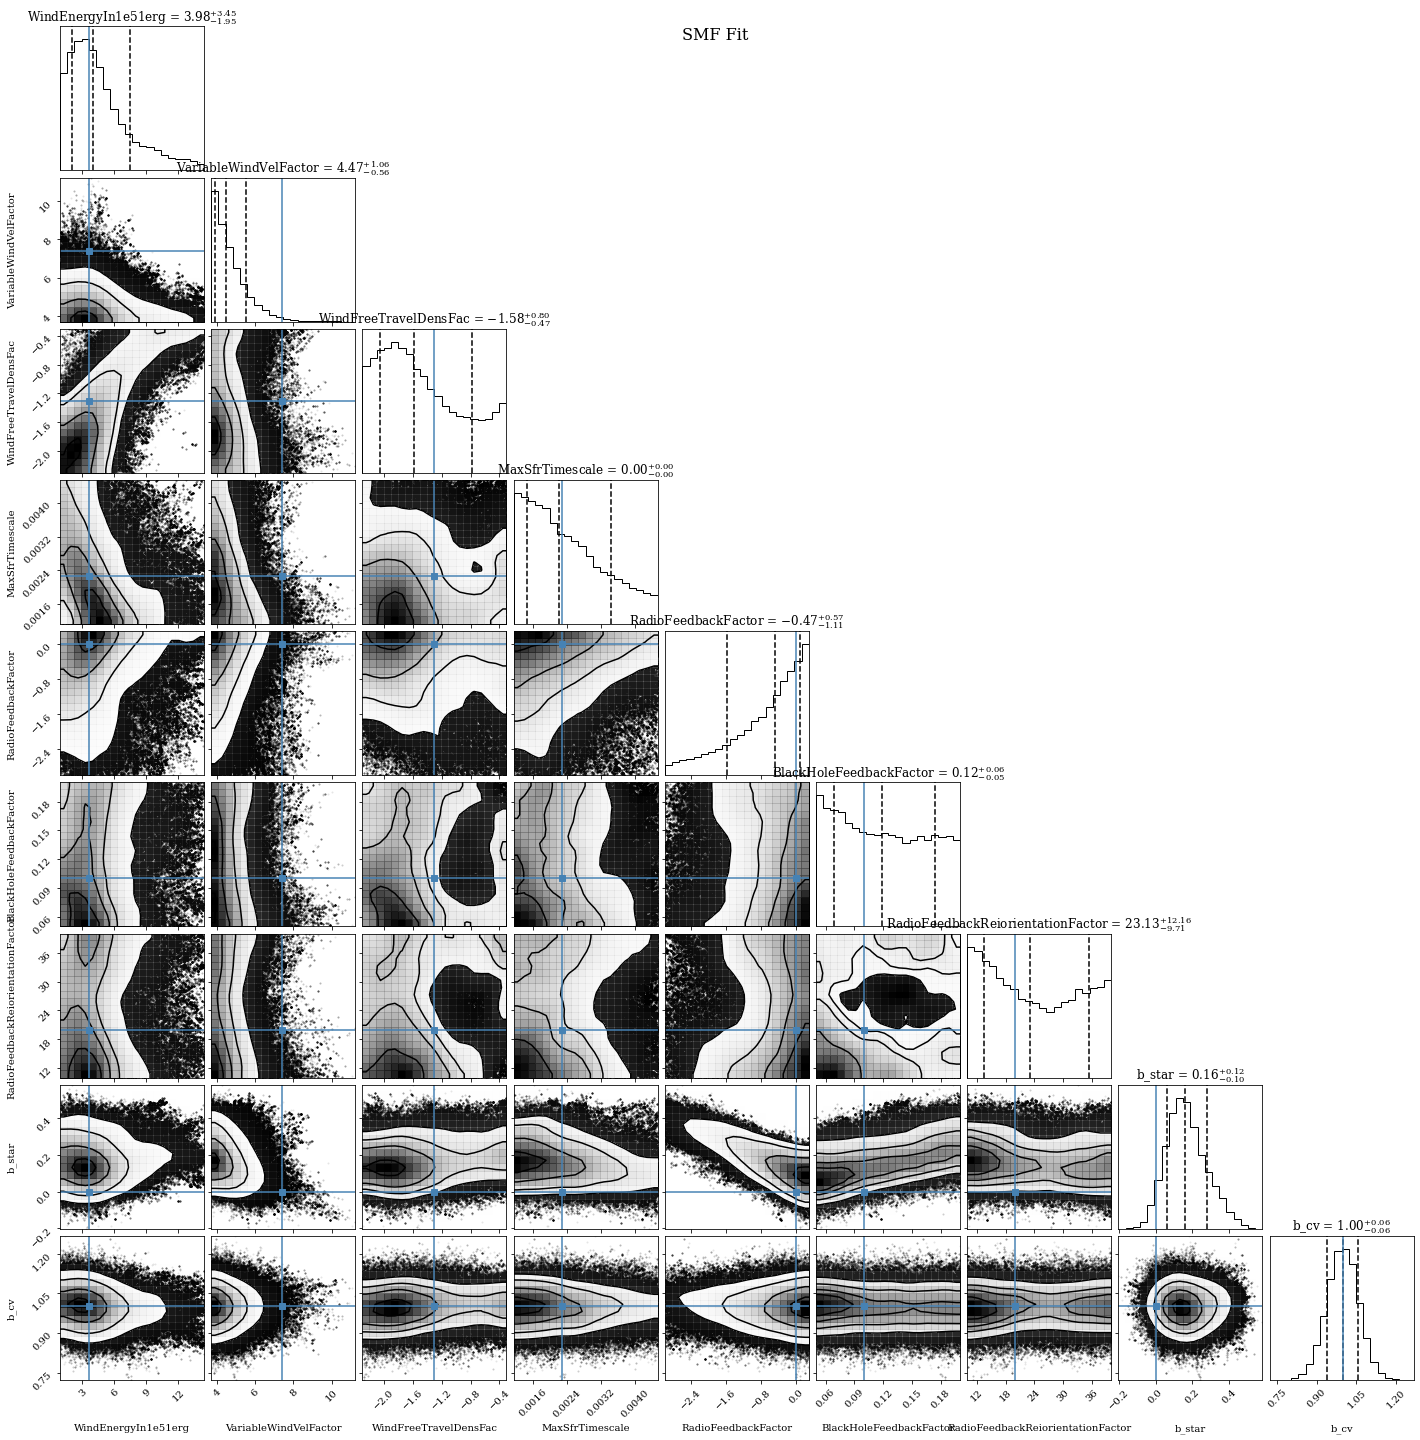


Summary Statistics (Median and 1-sigma uncertainty):
	WindEnergyIn1e51erg = 3.975_{-1.946}^{+3.447}
	VariableWindVelFactor = 4.467_{-0.563}^{+1.056}
	WindFreeTravelDensFac = -1.581_{-0.474}^{+0.805}
	MaxSfrTimescale = 0.002_{-0.001}^{+0.001}
	RadioFeedbackFactor = -0.471_{-1.113}^{+0.567}
	BlackHoleFeedbackFactor = 0.118_{-0.049}^{+0.056}
	RadioFeedbackReiorientationFactor = 23.126_{-9.709}^{+12.160}
	b_star = 0.158_{-0.096}^{+0.123}
	b_cv = 0.999_{-0.060}^{+0.058}


In [84]:
# Generate the corner plot 
fig = corner.corner(
    flat_samples[:,:], 
    labels=param_names, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30], 0.0, 1.0])
)

plt.suptitle("SMF Fit", fontsize=16)
plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.3f}_{{-{2:.3f}}}^{{+{3:.3f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

In [66]:
# Assuming 'prepare_theta', 'mass_bins', 'means', and 'stds' are defined in the global scope 
# as in the previous, corrected response.

def get_gp_prediction(theta_original, mstar, gp_model):
    """
    Takes a set of 7 parameters (in original physical units) and returns 
    the predicted GP mean and variance for the full SMF curve (across all mstar bins).
    """
    
    # 1. Standardize theta (using the globally defined prepare_theta function)
    theta_standardized = prepare_theta(theta_original)
    
    # 2. Construct 8D input vector (mstar and standardized theta)
    N_mass_bins = len(mstar)
    theta_vector = np.repeat(theta_standardized[np.newaxis, :], N_mass_bins, axis=0)
    
    # Full 8D input: [log10(M*), theta_1_std, ..., theta_7_std]
    gp_input = np.hstack([
        mstar[:, np.newaxis], # (N_mass_bins, 1)
        theta_vector          # (N_mass_bins, 7)
    ]) 

    # 3. Predict with gpytorch
    x_star = torch.from_numpy(gp_input).float() 
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive_dist = gp_model(x_star) 
        
    mu_pred = predictive_dist.mean.numpy()         # Predicted mean SMF curve
    var_emulator = predictive_dist.variance.numpy() # GP intrinsic variance
    
    return mu_pred, var_emulator

In [78]:
def plot_best_fit_smf(flat_samples, model_GAMA, gp_model):
    """
    Plots the observed Stellar-Mass Function along with the MCMC best-fit 
    prediction and associated uncertainties.
    """
    
    # 1. Identify the Best-Fit Parameters (Median of the posterior)
    best_fit_theta = np.median(flat_samples, axis=0)
    
    # 2. Get the Prediction for the Best-Fit Parameters
    GAMA = model_GAMA(GAMA_corr, best_fit_theta[7], best_fit_theta[8])[9:,:].T
    mstar = GAMA[0]
    obs_log_phi = GAMA[1]
    obs_uncertainty = GAMA[2]

    mu_pred, var_emulator = get_gp_prediction(best_fit_theta[:7], mstar, gp_model)

    # 3. Calculate Uncertainties
    
    # a. Uncertainty from the GP emulator itself (inner shaded region)
    std_emulator = np.sqrt(var_emulator)
    
    # b. Total Uncertainty (Emulator + Observation) (outer shaded region)
    std_total = np.sqrt(var_emulator + obs_uncertainty**2)
    
    # 4. Plotting
    fig, ax = plt.subplots(dpi=200)
        
    # A. Plot Observational Data
    ax.errorbar(
        mstar, 
        obs_log_phi, 
        yerr=obs_uncertainty, # Error bars show the observation uncertainty
        fmt='o', 
        color='k', 
        capsize=3, 
        zorder=3, # Bring to front
        label='Driver et al (2022)'
    )
    
    # B. Plot Total Uncertainty Region (The full 1-sigma uncertainty)
    ax.fill_between(
        mstar, 
        mu_pred - std_total, 
        mu_pred + std_total, 
        color='C0', 
        alpha=0.2, 
        zorder=1,
        label='Total $1\sigma$ Uncertainty'
    )
    
    # C. Plot Emulator Uncertainty (Inner region, optional but good for diagnostics)
    ax.fill_between(
        mstar, 
        mu_pred - std_emulator, 
        mu_pred + std_emulator, 
        color='C0', 
        alpha=0.5, 
        zorder=2,
        label='Emulator $1\sigma$ Uncertainty'
    )
    
    # D. Plot Best-Fit Mean Curve
    ax.plot(
        mstar, 
        mu_pred, 
        '-', 
        color='C0', 
        linewidth=3, 
        zorder=4,
        label='Best-Fit GP Prediction (Median $\\theta$)'
    )

    plt.plot(np.log10(zoom_smf['fiducial']['mstar'][0]), np.log10(zoom_smf['fiducial']['smf'][0]), label='Fiducial', color='black', linewidth=2)
    
    # E. Formatting
    ax.set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=14)
    ax.set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3})$', fontsize=14)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- HOW TO USE IT AFTER YOUR MCMC RUN ---

# Assuming you have run the MCMC and have your final chains:
# flat_samples = sampler.get_chain(discard=burnin, flat=True)

# plot_best_fit_smf(
#     flat_samples, 
#     mass_bins, 
#     obs_log_phi, 
#     obs_uncertainty, 
#     model
# )

#

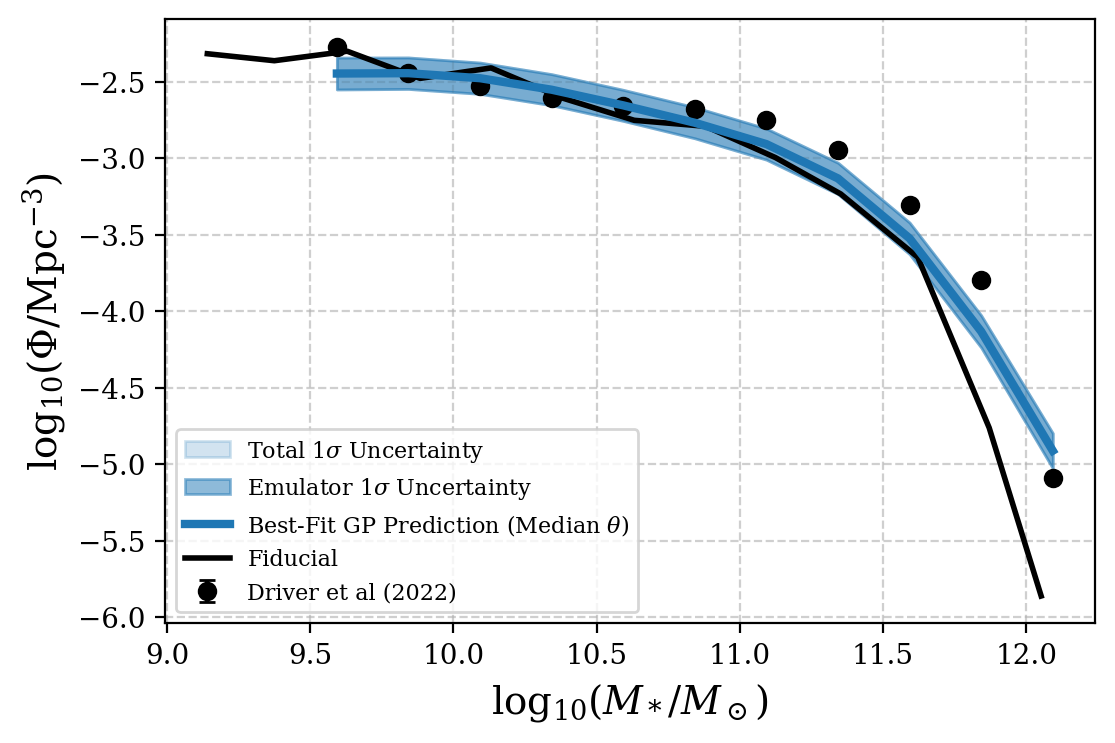

In [79]:
plot_best_fit_smf(
    flat_samples, 
    model_GAMA,
    model
)

In [69]:
fid_theta = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

Text(0.5, 1.0, 'Cumulative changes to Best-Fit Model')

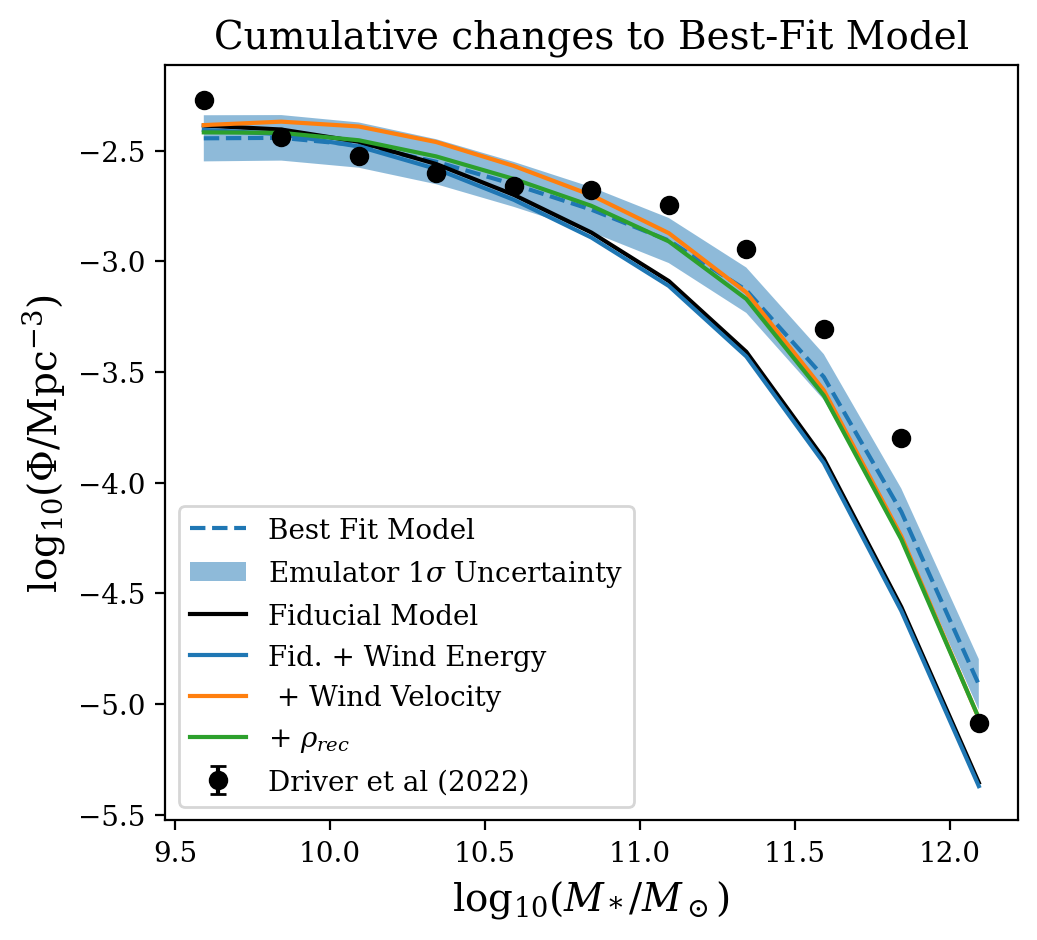

In [82]:
bf_theta = np.median(flat_samples, axis=0)

fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

GAMA = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])[9:,:].T
mstar = GAMA[0]
obs_log_phi = GAMA[1]
obs_uncertainty = GAMA[2]

ax.errorbar(
    mstar, 
    obs_log_phi, 
    yerr=obs_uncertainty, 
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Driver et al (2022)'
)

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta[:7], mstar, model)
ax.plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax.fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

# Plot fiducial model
fid_mu_pred, fid_var_emulator = get_gp_prediction(fid_theta, mstar, model)
ax.plot(mstar, fid_mu_pred, label='Fiducial Model', color='k')
# ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Wind velocity
ch_theta[1] = bf_theta[1]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C1', label=' + Wind Velocity')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C2', label='+ $\\rho_{rec}$')

ax.set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=14)
ax.set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3})$', fontsize=14)
ax.legend(fontsize=10)

ax.set_title("Cumulative changes to Best-Fit Model", fontsize=14)


Text(0.5, 1.0, 'One parameter changes to Best-Fit Model')

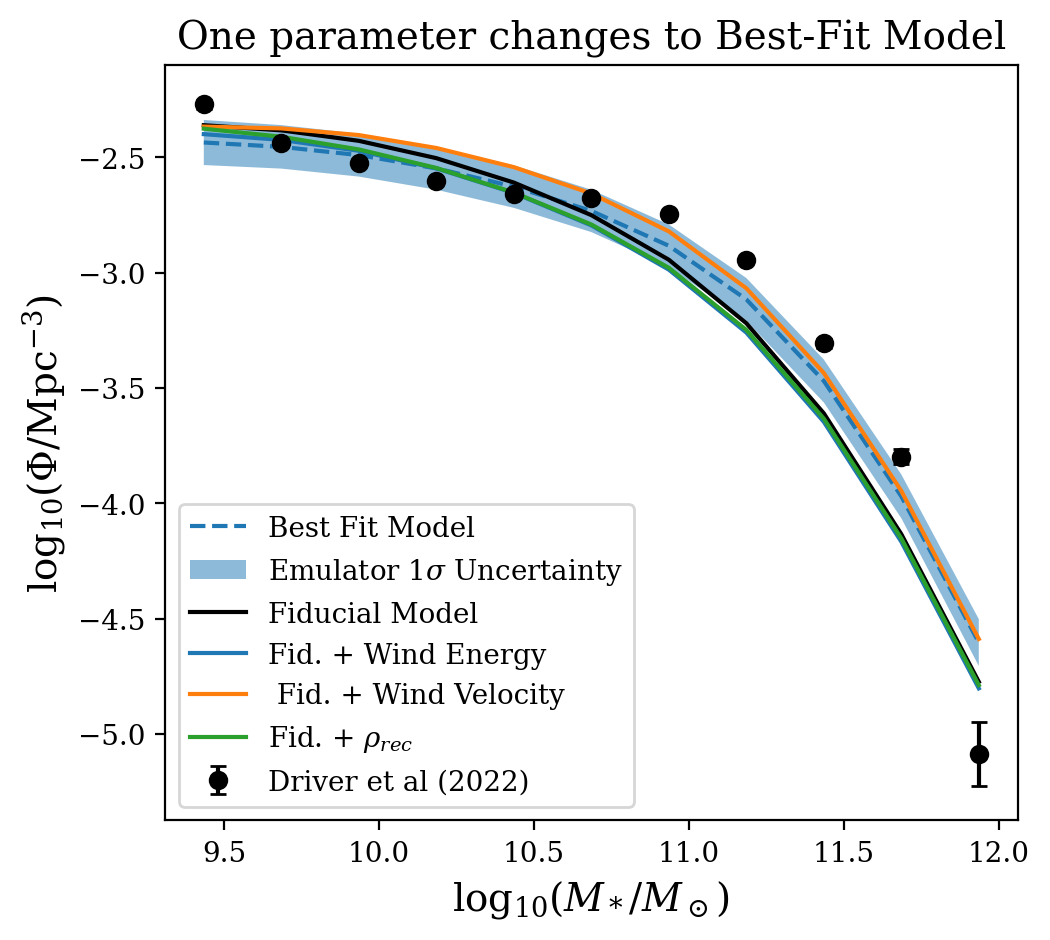

In [44]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.errorbar(
    mstar, 
    obs_log_phi, 
    yerr=obs_uncertainty, 
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Driver et al (2022)'
)

# Plot Best-Fit Mean Curve
bf_theta = np.median(flat_samples, axis=0)
mu_pred, var_emulator = get_gp_prediction(bf_theta, mstar, model)
ax.plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax.fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

cmap = plt.get_cmap('copper')

# Plot fiducial model
fid_mu_pred, fid_var_emulator = get_gp_prediction(fid_theta, mstar, model)
ax.plot(mstar, fid_mu_pred, label='Fiducial Model', color='k')
# ax.plot(np.log10(zoom_fgas['fiducial']['m500c'][0]), zoom_fgas['fiducial']['f_gas'][0], label='Fiducial', color='black', linewidth=2)

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Wind velocity
ch_theta[1] = bf_theta[1]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C1', label=' Fid. + Wind Velocity')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model)
ax.plot(mstar, ch_mu_pred, color='C2', label='Fid. + $\\rho_{rec}$')

ax.set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=14)
ax.set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3})$', fontsize=14)
ax.legend(fontsize=10)

ax.set_title("One parameter changes to Best-Fit Model", fontsize=14)


In [129]:
def get_theta_1p_vars(param_num, nvars):
    theta_1p_vars = {}

    delta = (upper_bound[param_num] - lower_bound[param_num]) / nvars

    for i in range(nvars+1):
        theta_1p_vars[i] = np.copy(fid_theta)
        theta_1p_vars[i][param_num] = fid_theta[param_num] + (i-2) * delta

    return theta_1p_vars

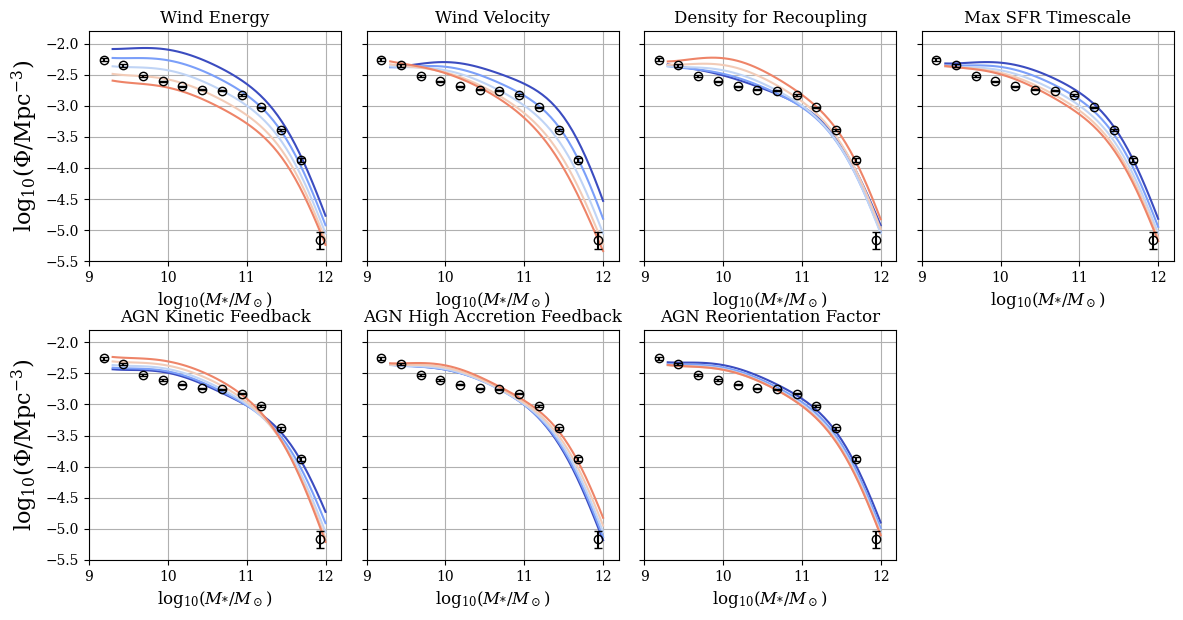

In [156]:
fig, ax = plt.subplots(2,4, dpi=100, sharey=True, figsize=(14,7))

ax[0,0].set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3})$', fontsize=16)
ax[1,0].set_ylabel('$\\log_{10}(\\Phi / \\mathrm{Mpc}^{-3})$', fontsize=16)

cmap = plt.get_cmap('coolwarm')

mstar_test = np.linspace(9.3,12,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']

mu_fid, var_fid = get_gp_prediction(fid_theta, mstar_test, model)

for j in range(7):
    ix = j//4
    jx = j%4

    ax[ix,jx].set_title(names[j], fontsize=12)
    ax[ix,jx].set_xlabel(r"$\log_{10}(M_{*}/M_\odot)$", fontsize=12)
    theta_vars = get_theta_1p_vars(j, 5)

    for i in range(5):
        # Our measurements
        mu_pred, var = get_gp_prediction(theta_vars[i], mstar_test, model)
        ax[ix,jx].plot(mstar_test, mu_pred, color=cmap(i/5))
    
    ax[ix,jx].grid()

    ax[ix,jx].errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=GAMA[:,2], color='k', marker='o', capsize=3, ms=6, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

    ax[ix,jx].set_xlim(9,12.2)
    ax[ix,jx].set_ylim(-5.5,-1.8)

ax[1,3].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.3)